In [5]:
# Import required libraries for NLP and recurrent neural networks

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    GRU,
    Dense
)

import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [6]:
# Load IMDB movie review dataset

max_features = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=max_features
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 25000
Testing samples: 25000


In [7]:
# Pad sequences to the same length

maxlen = 200

X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)

print(X_train.shape)
print(X_test.shape)

(25000, 200)
(25000, 200)


In [8]:
# Build SimpleRNN model for sentiment analysis

rnn_model = Sequential([

    # Convert word indexes into dense vectors
    Embedding(max_features, 128),

    # Recurrent layer
    SimpleRNN(64),

    # Hidden dense layer
    Dense(64, activation='relu'),

    # Output layer for binary classification
    Dense(1, activation='sigmoid')
])

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Compile SimpleRNN model

rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [13]:
# Train SimpleRNN model

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.6320 - loss: 0.6172 - val_accuracy: 0.7992 - val_loss: 0.4423
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.8612 - loss: 0.3246 - val_accuracy: 0.6612 - val_loss: 0.6667
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.9424 - loss: 0.1541 - val_accuracy: 0.8268 - val_loss: 0.5107


In [14]:
# Evaluate SimpleRNN model

loss_rnn, accuracy_rnn = rnn_model.evaluate(X_test, y_test)

print(f"SimpleRNN Accuracy: {accuracy_rnn * 100:.2f}%")

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8169 - loss: 0.5336
SimpleRNN Accuracy: 81.69%


In [15]:
# Build LSTM model

lstm_model = Sequential([

    Embedding(max_features, 128),

    # LSTM recurrent layer
    LSTM(64),

    Dense(64, activation='relu'),

    Dense(1, activation='sigmoid')
])

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Compile LSTM model

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train LSTM model

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 86ms/step - accuracy: 0.7772 - loss: 0.4532 - val_accuracy: 0.8456 - val_loss: 0.3627
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 82ms/step - accuracy: 0.9031 - loss: 0.2475 - val_accuracy: 0.8628 - val_loss: 0.3415
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 83ms/step - accuracy: 0.9384 - loss: 0.1675 - val_accuracy: 0.8672 - val_loss: 0.3478


In [17]:
# Evaluate LSTM model

loss_lstm, accuracy_lstm = lstm_model.evaluate(X_test, y_test)

print(f"LSTM Accuracy: {accuracy_lstm * 100:.2f}%")

782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.8648 - loss: 0.3587
LSTM Accuracy: 86.48%


In [18]:
# Build GRU model

gru_model = Sequential([

    Embedding(max_features, 128),

    # GRU recurrent layer
    GRU(64),

    Dense(64, activation='relu'),

    Dense(1, activation='sigmoid')
])

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Compile GRU model

gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train GRU model

history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 92ms/step - accuracy: 0.7744 - loss: 0.4589 - val_accuracy: 0.8664 - val_loss: 0.3293
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 90ms/step - accuracy: 0.9004 - loss: 0.2557 - val_accuracy: 0.8768 - val_loss: 0.3053
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 91ms/step - accuracy: 0.9355 - loss: 0.1718 - val_accuracy: 0.8652 - val_loss: 0.3381


In [20]:
# Evaluate GRU model

loss_gru, accuracy_gru = gru_model.evaluate(X_test, y_test)

print(f"GRU Accuracy: {accuracy_gru * 100:.2f}%")

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8572 - loss: 0.3578
GRU Accuracy: 85.72%


In [21]:
# Compare model accuracies

print("\nModel Comparison:")
print(f"SimpleRNN Accuracy: {accuracy_rnn * 100:.2f}%")
print(f"LSTM Accuracy: {accuracy_lstm * 100:.2f}%")
print(f"GRU Accuracy: {accuracy_gru * 100:.2f}%")


Model Comparison:
SimpleRNN Accuracy: 81.69%
LSTM Accuracy: 86.48%
GRU Accuracy: 85.72%


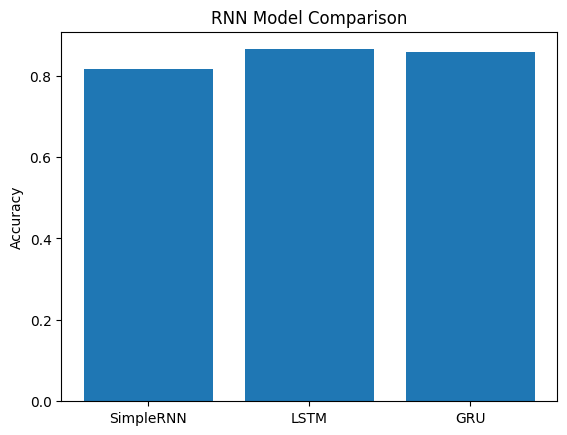

In [22]:
# Plot accuracy comparison

models = ['SimpleRNN', 'LSTM', 'GRU']
accuracies = [
    accuracy_rnn,
    accuracy_lstm,
    accuracy_gru
]

plt.bar(models, accuracies)

plt.title("RNN Model Comparison")
plt.ylabel("Accuracy")

plt.show()

In [23]:
# Decode one review from dataset

word_index = imdb.get_word_index()

reverse_word_index = {
    value: key for key, value in word_index.items()
}

decoded_review = ' '.join(
    [reverse_word_index.get(i - 3, '?') for i in X_test[0]]
)

print(decoded_review)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? please give this one a miss br br ? ? and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quite ? so all you madison fans give this a miss


In [24]:
# Predict sentiment for one review

prediction = gru_model.predict(X_test[0].reshape(1, -1))

print("Prediction probability:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Predicted sentiment: Positive")
else:
    print("Predicted sentiment: Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
Prediction probability: 0.055164516
Predicted sentiment: Negative


In [ ]:
# Final Conclusion:
# In this lab, recurrent neural networks were implemented for sentiment analysis.
# Three architectures were tested: SimpleRNN, LSTM and GRU.
# Text reviews were converted into numerical sequences using the IMDB dataset.
# Embedding layers transformed word indexes into dense vector representations.
# The models were trained and evaluated on movie review classification.
# LSTM and GRU achieved better performance than SimpleRNN because they can better preserve long-term dependencies in text sequences.
# GRU required fewer parameters and trained faster, while LSTM provided stable and accurate results.